In [1]:
import os, sys
PROJECT_ROOT = os.path.expanduser("~/projects/burn2scar")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from dotenv import load_dotenv
load_dotenv()

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from src.effis_loader import load_effis
from src.s2_pipeline import make_sh_config, process_fire, EXPORT_BANDS, MASK_COLORMAP
from src.hf_upload import init_hf, load_quota_state, save_quota_state, upload_and_cleanup

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

print(f"working dir: {os.getcwd()}")
print(f"config loaded: {len(cfg)} keys")

/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/eolearn/io/sentinelhub_process.py:36: SHDeprecationWarning: The module `sentinelhub.type_utils` is deprecated, use `sentinelhub.types` instead.
  from sentinelhub.type_utils import RawTimeIntervalType


working dir: /root/projects/burn2scar
config loaded: 26 keys


In [2]:
sh = make_sh_config(os.environ["SH_CLIENT_ID"], os.environ["SH_CLIENT_SECRET"])
api = init_hf(cfg["hf_repo_id"], os.environ["HF_TOKEN"])
os.makedirs(cfg["out_dir"], exist_ok=True)
os.makedirs(f"{cfg['out_dir']}/qa_thumbnails", exist_ok=True)
print("CDSE + HF connected")

CDSE + HF connected


max_area_ha filter: 2952 -> 2790 fires
2773 fires queued (from 2790 before southern-France filter)


/tmp/ipykernel_3648506/1780526324.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  southern_ok = ~is_fr | (fires_all.geometry.centroid.y <= cfg["southern_france_max_lat"])


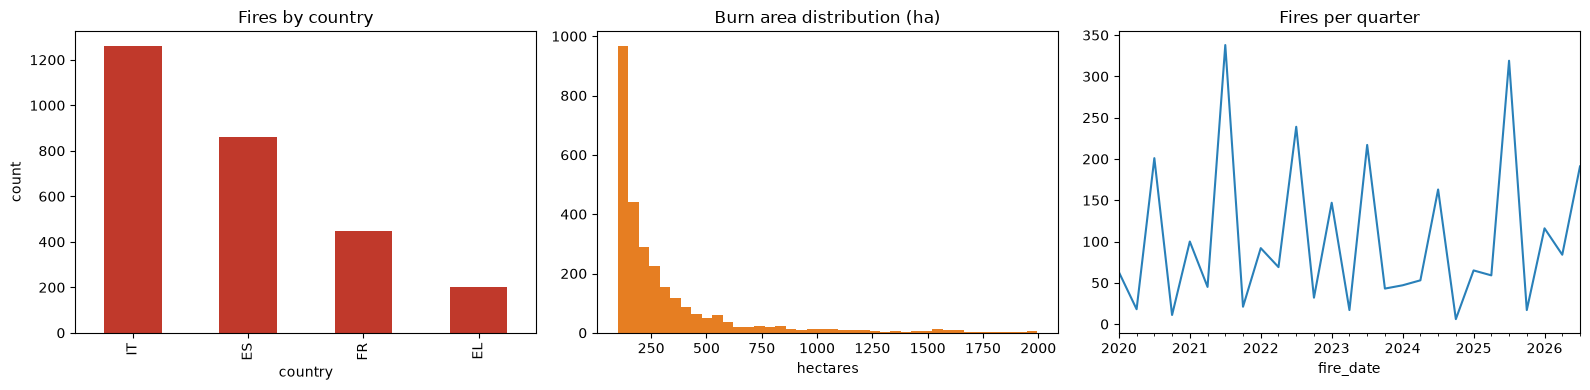

,fire_id,country,fire_date,area_ha
0,effis_203702,ES,2022-06-18 12:02:00,1995
1,effis_41008,IT,2020-08-01 11:18:00,1987
2,effis_281574,ES,2025-09-18 13:21:00,1987
3,effis_562641,ES,2026-07-22 19:55:00,1966
4,effis_52171,IT,2021-08-10 20:10:00,1950
5,effis_205944,ES,2022-07-15 10:30:00,1944
6,effis_206860,ES,2022-07-25 12:57:00,1935
7,effis_42353,ES,2020-08-15 12:48:00,1929
8,effis_278315,EL,2025-08-08 11:25:00,1901
9,effis_42303,EL,2020-08-22 09:25:00,1894


In [3]:
fires_all = load_effis(cfg["effis_path"], countries=cfg["countries"],
                       start_date=cfg["start_date"], end_date=cfg["end_date"],
                       min_area_ha=cfg["min_area_ha"])
if cfg.get("max_area_ha"):
    before = len(fires_all)
    fires_all = fires_all[fires_all["area_ha"] <= cfg["max_area_ha"]]
    print(f"max_area_ha filter: {before} -> {len(fires_all)} fires")

is_fr = fires_all["country"] == "FR"
southern_ok = ~is_fr | (fires_all.geometry.centroid.y <= cfg["southern_france_max_lat"])
fires = fires_all[southern_ok].reset_index(drop=True)

print(f"{len(fires)} fires queued (from {len(fires_all)} before southern-France filter)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fires["country"].value_counts().plot(kind="bar", ax=axes[0], color="#c0392b")
axes[0].set_title("Fires by country"); axes[0].set_ylabel("count")

axes[1].hist(fires["area_ha"], bins=40, color="#e67e22")
axes[1].set_title("Burn area distribution (ha)"); axes[1].set_xlabel("hectares")

fires.set_index("fire_date")["area_ha"].resample("QE").count().plot(ax=axes[2], color="#2980b9")
axes[2].set_title("Fires per quarter")

plt.tight_layout()
plt.savefig(f"{cfg['out_dir']}/fires_overview.png", dpi=120)
plt.show()

display(fires[["fire_id","country","fire_date","area_ha"]].head(10))

In [4]:
MASK_LABELS = {0:"clear", 2:"fresh burn", 3:"old burn", 4:"cloud", 5:"shadow", 6:"water", 255:"nodata"}

def load_rgb(s2_path):
    with rasterio.open(s2_path) as src:
        r = src.read(EXPORT_BANDS.index("B04") + 1).astype(np.float32)
        g = src.read(EXPORT_BANDS.index("B03") + 1).astype(np.float32)
        b = src.read(EXPORT_BANDS.index("B02") + 1).astype(np.float32)
    rgb = np.stack([r, g, b], axis=-1) / 10000.0
    valid = rgb[rgb > 0]
    lo, hi = np.percentile(valid, [2, 98]) if valid.size else (0, 1)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

def load_mask_rgb(mask_path):
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    out = np.zeros((*m.shape, 3), dtype=np.float32)
    for val, rgba in MASK_COLORMAP.items():
        out[m == val] = np.array(rgba[:3]) / 255.0
    return out, m

def visualize_fire(s2_path, mask_path, title="", save_path=None):
    rgb = load_rgb(s2_path)
    mask_rgb, m = load_mask_rgb(mask_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb); axes[0].set_title(f"{title} — true colour"); axes[0].axis("off")
    axes[1].imshow(mask_rgb); axes[1].set_title("Label mask"); axes[1].axis("off")

    present = sorted(v for v in MASK_COLORMAP if (m == v).any())
    handles = [plt.Rectangle((0,0),1,1, color=np.array(MASK_COLORMAP[v][:3])/255.0) for v in present]
    axes[1].legend(handles, [MASK_LABELS[v] for v in present],
                   loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=100, bbox_inches="tight")
    return fig

/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(


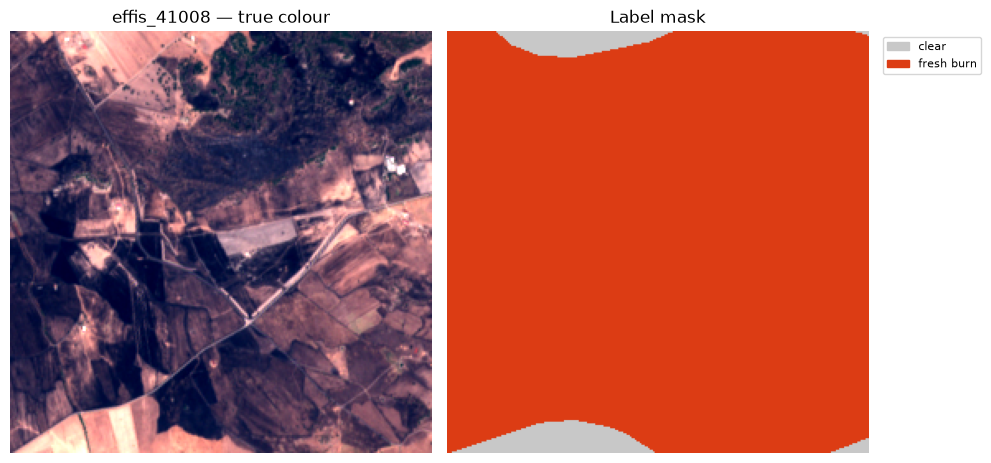

uploaded 1.1 MB


In [5]:
test_fire = fires.iloc[1]
files = process_fire(test_fire, fires, cfg, sh)

if files:
    s2_path = next(f for f in files if f.endswith("_s2.tif"))
    mask_path = next(f for f in files if f.endswith("_mask.tif"))
    visualize_fire(s2_path, mask_path, title=test_fire["fire_id"],
                   save_path=f"{cfg['out_dir']}/qa_thumbnails/{test_fire['fire_id']}.png")
    plt.show()

    fire_dir = os.path.dirname(os.path.dirname(files[0]))
    size = upload_and_cleanup(api, cfg["hf_repo_id"], fire_dir, test_fire["fire_id"])
    print(f"uploaded {size/1e6:.1f} MB" if size else "upload failed")
else:
    print("no usable scene found for this fire — try fires.iloc[1] etc.")

resumed: 7 fires already done


/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(


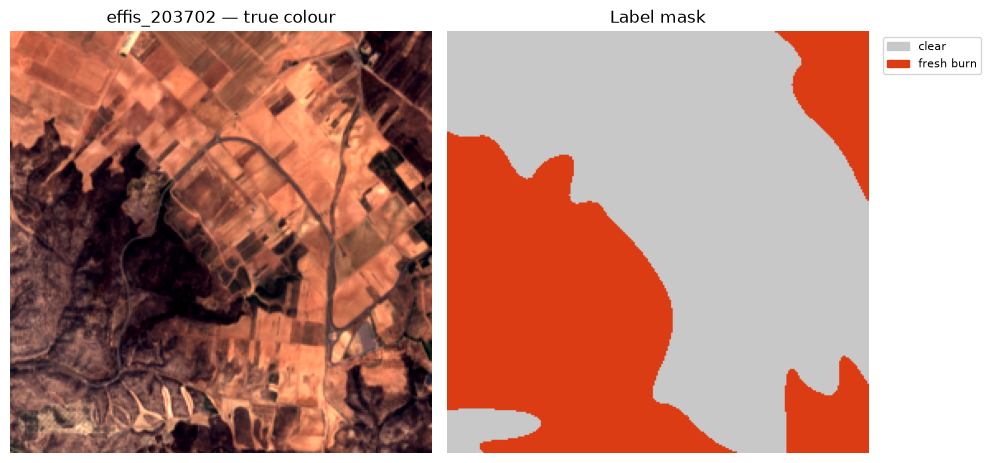

[1] effis_203702: 1.2 MB uploaded  (total 0.01/93 GB)


/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(
No files have been modified since last commit. Skipping to prevent empty commit.


[2] effis_41008: 1.1 MB uploaded  (total 0.01/93 GB)


/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(


[3] effis_281574: 1.2 MB uploaded  (total 0.01/93 GB)


/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(


[4] effis_562641: 1.1 MB uploaded  (total 0.01/93 GB)


/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(


KeyboardInterrupt: 

In [6]:
VISUALIZE_EVERY = 5
MAX_FIRES_THIS_SESSION = 20   # raise or remove once you trust it; full bulk run stays in run_extraction.py

quota_path = os.path.join(cfg["out_dir"], "quota_state.json")
state = load_quota_state(quota_path)
running_by_country = state["running_by_country"]
done_fire_ids = set(state["done_fire_ids"])
print(f"resumed: {len(done_fire_ids)} fires already done")

country_budget_bytes = {c: frac * cfg["total_budget_gb"] * 1e9 for c, frac in cfg["country_quota"].items()}
processed = 0

for _, fire_row in fires.iterrows():
    if processed >= MAX_FIRES_THIS_SESSION:
        print("session cap reached — re-run this cell to continue"); break
    fid, country = fire_row["fire_id"], fire_row["country"]
    if fid in done_fire_ids:
        continue
    if running_by_country.get(country, 0) >= country_budget_bytes.get(country, 0):
        continue
    if sum(running_by_country.values()) >= cfg["total_budget_gb"] * 1e9:
        print("total budget reached"); break

    run_cfg = dict(cfg); run_cfg["ocm_device"] = "cuda:0"
    files = process_fire(fire_row, fires, run_cfg, sh)
    if not files:
        continue

    s2_path = next(f for f in files if f.endswith("_s2.tif"))
    mask_path = next(f for f in files if f.endswith("_mask.tif"))

    if processed % VISUALIZE_EVERY == 0:
        visualize_fire(s2_path, mask_path, title=fid,
                       save_path=f"{cfg['out_dir']}/qa_thumbnails/{fid}.png")
        plt.show()

    fire_dir = os.path.dirname(os.path.dirname(files[0]))
    size = upload_and_cleanup(api, cfg["hf_repo_id"], fire_dir, fid)
    if size is not None:
        running_by_country[country] = running_by_country.get(country, 0) + size
        done_fire_ids.add(fid)
        save_quota_state(quota_path, {"running_by_country": running_by_country,
                                      "done_fire_ids": list(done_fire_ids)})
        processed += 1
        print(f"[{processed}] {fid}: {size/1e6:.1f} MB uploaded  "
             f"(total {sum(running_by_country.values())/1e9:.2f}/{cfg['total_budget_gb']} GB)")

In [8]:
import numpy as np
import shutil
from src.s2_pipeline import MASK_CLEAR, MASK_FRESH, MASK_OLD, MASK_CLOUD, MASK_SHADOW, MASK_WATER

sample = fires.sample(15, random_state=7)
class_pixel_totals = {v: 0 for v in [MASK_CLEAR, MASK_FRESH, MASK_OLD, MASK_CLOUD, MASK_SHADOW, MASK_WATER]}
total_pixels = 0
per_fire_summary = []

for _, row in sample.iterrows():
    files = process_fire(row, fires, cfg, sh)
    if not files:
        continue
    mask_path = next(f for f in files if f.endswith("_mask.tif"))
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    total_pixels += m.size
    fire_classes = {}
    for v in class_pixel_totals:
        n = (m == v).sum()
        class_pixel_totals[v] += n
        if n > 0:
            fire_classes[MASK_LABELS[v]] = round(100 * n / m.size, 1)
    per_fire_summary.append((row["fire_id"], fire_classes))

    fire_dir = os.path.dirname(os.path.dirname(files[0]))
    shutil.rmtree(fire_dir, ignore_errors=True)  # diagnostic only, not uploading

print(f"\n{'='*60}\nCLASS PRESENCE ACROSS {len(per_fire_summary)} FIRES\n{'='*60}")
for fid, classes in per_fire_summary:
    print(f"{fid}: {classes}")

print(f"\n{'='*60}\nOVERALL PIXEL %\n{'='*60}")
for v, n in class_pixel_totals.items():
    print(f"{MASK_LABELS[v]:<12}: {100*n/max(total_pixels,1):.2f}%")

/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 256 and overlap to 128.
  patch_overlap, patch_size = check_patch_size(
/root/projects/iride_onboard-burnscar-mapper/.venv/lib/python3.12/site-p


CLASS PRESENCE ACROSS 15 FIRES
effis_50713: {'clear': np.float64(70.3), 'fresh burn': np.float64(29.6), 'water': np.float64(0.1)}
effis_52279: {'clear': np.float64(75.4), 'fresh burn': np.float64(22.3), 'water': np.float64(2.4)}
effis_266476: {'clear': np.float64(76.1), 'fresh burn': np.float64(23.9)}
effis_215161: {'clear': np.float64(68.5), 'fresh burn': np.float64(28.2), 'cloud': np.float64(3.3)}
effis_205085: {'clear': np.float64(82.3), 'fresh burn': np.float64(17.7)}
effis_50846: {'clear': np.float64(47.8), 'fresh burn': np.float64(52.1), 'water': np.float64(0.1)}
effis_294317: {'clear': np.float64(59.6), 'fresh burn': np.float64(29.1), 'cloud': np.float64(9.3), 'shadow': np.float64(2.0)}
effis_273227: {'clear': np.float64(82.4), 'fresh burn': np.float64(17.6), 'water': np.float64(0.0)}
effis_222615: {'clear': np.float64(73.0), 'fresh burn': np.float64(27.0), 'water': np.float64(0.0)}
effis_561501: {'clear': np.float64(49.7), 'fresh burn': np.float64(50.1), 'water': np.float64(0.